In [99]:
#TO INSTALL OPENCV IN OUR ENVURIRONMENT
!pip install opencv-python

In [100]:
#TO IMPORT CV2 MODULE AS CV
import cv2 as cv

In [101]:
#TO READ AN IMAGE USING CV.IMREAD
image = cv.imread('./index.jpg')

In [102]:
#TO CHECK IF OUR IMREAD FUNCTION IS WORKING OR NOT
image.shape

(275, 183, 3)

In [103]:
#A MODULE TO PLOT IMAGE IN FORM OF GRAPH
import matplotlib.pyplot as plt

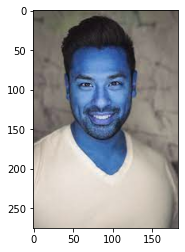

In [104]:
#TO SHOW AN IMAGE
plt.imshow(image)

In [105]:
#TO SHOW AN IMAGE USING IMSHOW FUNCTION
while True:
    cv.imshow('result',image)
    #STOPING CONDITION FOR OUR WHILE LOOP
    if cv.waitKey(2)==27:
        break;
cv.destroyAllWindows()

In [106]:
#TO ATTACH HAAR DATA FILE FOR FACE DETECTION
haar_data = cv.CascadeClassifier('./data.xml')

In [107]:
#TO GET THE COODINATES OF FACE IN AN IMAGE
haar_data.detectMultiScale(image)

array([[37, 56, 96, 96]], dtype=int32)

In [108]:
while True:
    faces = haar_data.detectMultiScale(image)
    for x,y,w,h in faces:
        #TO DRAW A RECTANGLE ON THE FACE IN AN IMAGE WE ARE PASSING IMAGE, STARTING COORDINATE, ENDING COORDINATE
        # COLOR OF RECTANGLE, THICKNESS OF OUTLINE
        cv.rectangle(image,(x,y),(x+w,y+h),(255,255,0),2)
    cv.imshow('result',image)
    if cv.waitKey(2)==27:
        break;
cv.destroyAllWindows()

In [12]:
capture_cam = cv.VideoCapture(0)
data_without_mask = []
while True:
    flag,img = capture_cam.read()
    if flag:
        faces = haar_data.detectMultiScale(img)
        for x,y,w,h in faces:
            cv.rectangle(img,(x,y),(x+w,y+h),(255,255,0),2)
            face = img[y:y+h, x:x+w, :]
            face = cv.resize(face,(50,50))
#             print(len(data))
            if(len(data)<400):
                data_without_mask.append(face)
        cv.imshow('result',img)
        if(cv.waitKey(2)==27 or len(data_without_mask)>=200):
            break;
capture_cam.release()
cv.destroyAllWindows()

In [13]:
import numpy as np

In [17]:
np.save('without_mask.npy',data_without_mask)

In [109]:
without_mask = np.load('./without_mask.npy')

In [110]:
without_mask.shape

(200, 50, 50, 3)

In [20]:
capture_cam = cv.VideoCapture(0)
data_with_mask = []
while True:
    flag,img = capture_cam.read()
    if flag:
        faces = haar_data.detectMultiScale(img)
        for x,y,w,h in faces:
            cv.rectangle(img,(x,y),(x+w,y+h),(255,255,0),2)
            face = img[y:y+h, x:x+w, :]
            face = cv.resize(face,(50,50))
#             print(len(data))
            if(len(data_with_mask)<400):
                data_with_mask.append(face)
        cv.imshow('result',img)
        if(cv.waitKey(2)==27 or len(data_with_mask)>=200):
            break;
capture_cam.release()
cv.destroyAllWindows()

In [18]:
np.save('with_mask.npy',data)

NameError: name 'data' is not defined

In [111]:
with_mask = np.load('./with_mask.npy')

In [112]:
# converts collected data from bgr images to grayscale
without_mask = np.dot(without_mask[...,:3], [0.1140, 0.5870, 0.2989])
with_mask = np.dot(with_mask[...,:3], [0.1140, 0.5870, 0.2989])

In [113]:
print(without_mask.shape)
print(with_mask.shape)

(200, 50, 50)
(200, 50, 50)


In [114]:
without_mask = without_mask.reshape((without_mask.shape[0], without_mask.shape[1] * without_mask.shape[2]))
with_mask = with_mask.reshape((with_mask.shape[0], with_mask.shape[1] * with_mask.shape[2]))

In [115]:
print(without_mask.shape)
print(with_mask.shape)

(200, 2500)
(200, 2500)


In [116]:
X_DATA = np.r_[without_mask , with_mask]
Y_DATA = np.zeros(X_DATA.shape[0])
Y_DATA[200:] = 1.0

In [117]:
names = {0: 'No Mask Detected',1: 'Mask Detected'}

In [118]:
from sklearn.svm import SVC

In [119]:
from sklearn.metrics import accuracy_score

In [120]:
from sklearn.model_selection import train_test_split

In [121]:
x_train, x_test, y_train, y_test = train_test_split(X_DATA,Y_DATA,test_size = 0.25,random_state=42)

In [122]:
x_train.shape

(300, 2500)

In [123]:
x_test[0].shape

(2500,)

In [124]:
svm = SVC()
svm.fit(x_train, y_train)

SVC()

In [125]:
y_pred = svm.predict(x_test)

In [126]:
accuracy_score(y_test, y_pred)

1.0

In [139]:
image = cv.imread('./train/with_mask/-110603108-gettyimages-533567012.jpg')

In [140]:
faces = haar_data.detectMultiScale(image)

In [141]:
for x,y,w,h in faces:
  cv.rectangle(image, (x,y), (x+w,y+h), (255,255,0), 2)
  face = image[y:y+h, x:x+w, :]
  face = cv.resize(face, (50,50))
  face = np.dot(face[...,:3], [0.1140, 0.5870, 0.2989])
  prediction = svm.predict([face.reshape(2500)])[0]
  n = names[int(prediction)]
  print(n)

Mask Detected


In [155]:
img = cv.imread('./train/without_mask/156.jpg')

In [156]:
for x,y,w,h in faces:
  cv.rectangle(img, (x,y), (x+w,y+h), (255,255,0), 2)
  face = img[y:y+h, x:x+w, :]
  face = cv.resize(face, (50,50))
  face = np.dot(face[...,:3], [0.1140, 0.5870, 0.2989])
  prediction = svm.predict([face.reshape(2500)])[0]
  n = names[int(prediction)]
  print(n)

No Mask Detected


In [158]:
capture_cam = cv.VideoCapture(0)
while True:
    flag,image = capture_cam.read()
    if flag:
        faces = haar_data.detectMultiScale(image)
    for x,y,w,h in faces:
      cv.rectangle(image, (x,y), (x+w,y+h), (255,255,0), 2)
      face = image[y:y+h, x:x+w, :]
      face = cv.resize(face, (50,50))
      face = np.dot(face[...,:3], [0.1140, 0.5870, 0.2989])
      prediction = svm.predict([face.reshape(2500)])[0]
      if(prediction==1):
        cv.rectangle(image, (x,y), (x+w,y+h), (0,255,0), 2)
        n = names[int(prediction)]
        print(n)
      if(prediction==0):
        cv.rectangle(image, (x,y), (x+w,y+h), (0,0,255), 2)
        n = names[int(prediction)]
        print(n)
      cv.imshow('result',image)
    if cv.waitKey(2)==27:
            break;
capture_cam.release()
cv.destroyAllWindows()
    

No Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
Mask Detected
No Mask Detected
Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
Mask Detected
No Mask Detected
No Mask Detected
Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
Mask Detected
Mask Detected
Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
No Mask Detected
No Mask De